In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import json

print("="*70)
print("BRAIN TUMOR CLASSIFICATION - FINAL MODEL COMPARISON")
print("="*70)

BRAIN TUMOR CLASSIFICATION - FINAL MODEL COMPARISON


In [2]:
model_results = {
    'VGG19': {
        'test_accuracy': 0.8971,
        'training_accuracy': 0.9133,
        'validation_accuracy': 0.8841,
        'parameters': 20419396,
        'training_time': 'Medium',
        'epochs_trained': 30,
        'fine_tuned': True,
        'before_finetuning': 0.8377
    },
    'ResNet152': {
        'test_accuracy': 0.7119,
        'training_accuracy': 0.7067,
        'validation_accuracy': 0.7119,
        'parameters': 60000000,  # Approximate
        'training_time': 'High',
        'epochs_trained': 40,
        'fine_tuned': False,
        'before_finetuning': None
    },
    'MobileNetV3': {
        'test_accuracy': 0.7058,
        'training_accuracy': 0.7041,
        'validation_accuracy': 0.7058,
        'parameters': 5000000,  # Approximate
        'training_time': 'Low',
        'epochs_trained': 30,
        'fine_tuned': False,
        'before_finetuning': None
    }
}

In [3]:
print("\n" + "="*70)
print("MODEL PERFORMANCE COMPARISON")
print("="*70)
print(f"{'Model':<15} {'Test Acc':<12} {'Val Acc':<12} {'Parameters':<15} {'Fine-Tuned'}")
print("-"*70)
for model_name, data in model_results.items():
    test_acc = f"{data['test_accuracy']*100:.2f}%"
    val_acc = f"{data['validation_accuracy']*100:.2f}%"
    params = f"{data['parameters']/1e6:.1f}M"
    fine_tuned = "Yes" if data['fine_tuned'] else "No"
    print(f"{model_name:<15} {test_acc:<12} {val_acc:<12} {params:<15} {fine_tuned}")


MODEL PERFORMANCE COMPARISON
Model           Test Acc     Val Acc      Parameters      Fine-Tuned
----------------------------------------------------------------------
VGG19           89.71%       88.41%       20.4M           Yes
ResNet152       71.19%       71.19%       60.0M           No
MobileNetV3     70.58%       70.58%       5.0M            No


In [4]:
best_model = max(model_results.items(), key=lambda x: x[1]['test_accuracy'])
print(f"\n Best Model: {best_model[0]} with {best_model[1]['test_accuracy']*100:.2f}% accuracy")



 Best Model: VGG19 with 89.71% accuracy


In [5]:
fig = plt.figure(figsize=(20, 12))

<Figure size 2000x1200 with 0 Axes>

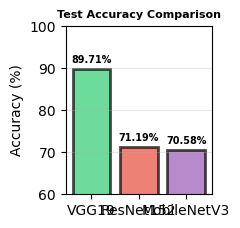

In [15]:
ax1 = plt.subplot(2, 3, 1)
models = list(model_results.keys())
test_accs = [model_results[m]['test_accuracy']*100 for m in models]
colors = ['#2ecc71', '#e74c3c', '#9b59b6']
bars = ax1.bar(models, test_accs, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax1.set_title('Test Accuracy Comparison', fontsize=8, fontweight='bold')
ax1.set_ylabel('Accuracy (%)', fontsize=10)
ax1.set_ylim([60, 100])
ax1.grid(axis='y', alpha=0.3)
for i, (bar, acc) in enumerate(zip(bars, test_accs)):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 1,
            f'{acc:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=7)

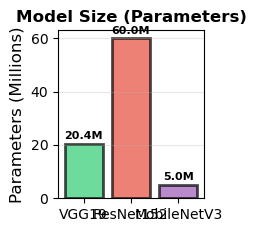

In [17]:
ax2 = plt.subplot(2, 3, 2)
params = [model_results[m]['parameters']/1e6 for m in models]
bars = ax2.bar(models, params, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax2.set_title('Model Size (Parameters)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Parameters (Millions)', fontsize=12)
ax2.grid(axis='y', alpha=0.3)
for bar, p in zip(bars, params):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 1,
            f'{p:.1f}M', ha='center', va='bottom', fontweight='bold', fontsize=8)

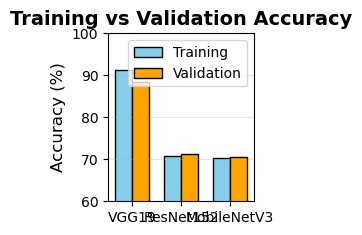

In [18]:
ax3 = plt.subplot(2, 3, 3)
x = np.arange(len(models))
width = 0.35
train_accs = [model_results[m]['training_accuracy']*100 for m in models]
val_accs = [model_results[m]['validation_accuracy']*100 for m in models]
bars1 = ax3.bar(x - width/2, train_accs, width, label='Training', color='skyblue', edgecolor='black')
bars2 = ax3.bar(x + width/2, val_accs, width, label='Validation', color='orange', edgecolor='black')
ax3.set_title('Training vs Validation Accuracy', fontsize=14, fontweight='bold')
ax3.set_ylabel('Accuracy (%)', fontsize=12)
ax3.set_xticks(x)
ax3.set_xticklabels(models)
ax3.legend()
ax3.set_ylim([60, 100])
ax3.grid(axis='y', alpha=0.3)

(60.0, 100.0)

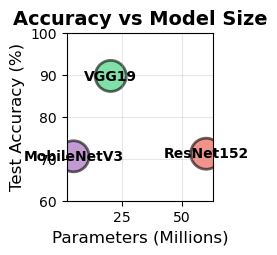

In [19]:
ax4 = plt.subplot(2, 3, 4)
scatter_params = [model_results[m]['parameters']/1e6 for m in models]
scatter_accs = [model_results[m]['test_accuracy']*100 for m in models]
scatter = ax4.scatter(scatter_params, scatter_accs, s=500, c=colors, alpha=0.6, edgecolors='black', linewidth=2)
for i, model in enumerate(models):
    ax4.annotate(model, (scatter_params[i], scatter_accs[i]), 
                ha='center', va='center', fontweight='bold', fontsize=10)
ax4.set_title('Accuracy vs Model Size', fontsize=14, fontweight='bold')
ax4.set_xlabel('Parameters (Millions)', fontsize=12)
ax4.set_ylabel('Test Accuracy (%)', fontsize=12)
ax4.grid(True, alpha=0.3)
ax4.set_ylim([60, 100])

Text(0.5, 86.74000000000001, '+5.94%')

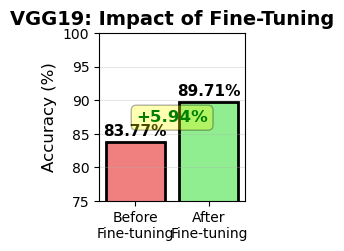

In [20]:
ax5 = plt.subplot(2, 3, 5)
vgg19_before = model_results['VGG19']['before_finetuning'] * 100
vgg19_after = model_results['VGG19']['test_accuracy'] * 100
improvement = vgg19_after - vgg19_before
categories = ['Before\nFine-tuning', 'After\nFine-tuning']
values = [vgg19_before, vgg19_after]
bars = ax5.bar(categories, values, color=['lightcoral', 'lightgreen'], edgecolor='black', linewidth=2)
ax5.set_title('VGG19: Impact of Fine-Tuning', fontsize=14, fontweight='bold')
ax5.set_ylabel('Accuracy (%)', fontsize=12)
ax5.set_ylim([75, 100])
ax5.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, values):
    height = bar.get_height()
    ax5.text(bar.get_x() + bar.get_width()/2., height + 0.5,
            f'{val:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)
ax5.text(0.5, (vgg19_before + vgg19_after)/2, f'+{improvement:.2f}%', 
        ha='center', fontsize=12, fontweight='bold', color='green',
        bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.3))

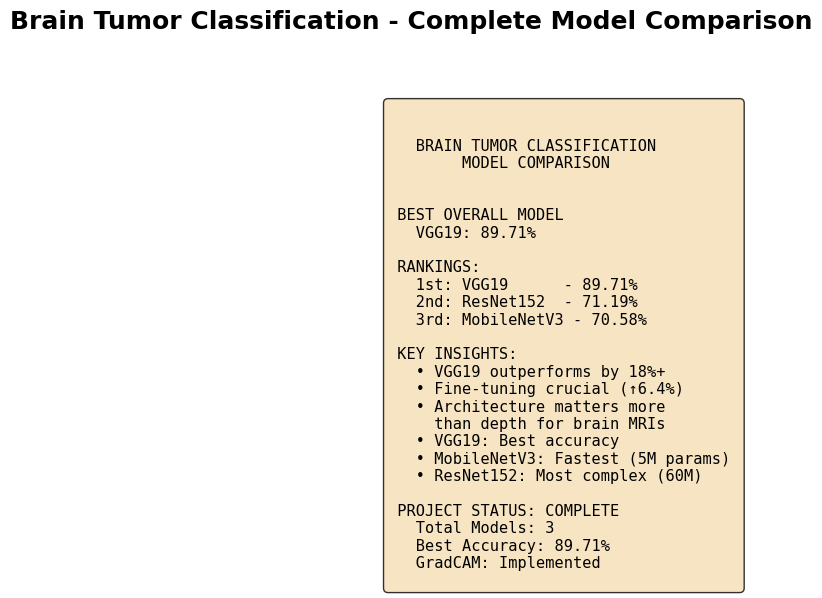

In [21]:
ax6 = plt.subplot(2, 3, 6)
ax6.axis('off')

summary_text = f"""

   BRAIN TUMOR CLASSIFICATION         
        MODEL COMPARISON              


 BEST OVERALL MODEL
   VGG19: 89.71%

 RANKINGS:
   1st: VGG19      - 89.71% 
   2nd: ResNet152  - 71.19%
   3rd: MobileNetV3 - 70.58%

 KEY INSIGHTS:
   • VGG19 outperforms by 18%+
   • Fine-tuning crucial (↑6.4%)
   • Architecture matters more
     than depth for brain MRIs
   • VGG19: Best accuracy
   • MobileNetV3: Fastest (5M params)
   • ResNet152: Most complex (60M)

 PROJECT STATUS: COMPLETE
   Total Models: 3
   Best Accuracy: 89.71%
   GradCAM: Implemented
"""

ax6.text(0.1, 0.9, summary_text, transform=ax6.transAxes,
        fontsize=11, verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.suptitle('Brain Tumor Classification - Complete Model Comparison', 
            fontsize=18, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig('models/final_model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [22]:
comparison_df = pd.DataFrame({
    'Model': models,
    'Test Accuracy (%)': [f"{model_results[m]['test_accuracy']*100:.2f}" for m in models],
    'Validation Accuracy (%)': [f"{model_results[m]['validation_accuracy']*100:.2f}" for m in models],
    'Training Accuracy (%)': [f"{model_results[m]['training_accuracy']*100:.2f}" for m in models],
    'Parameters (M)': [f"{model_results[m]['parameters']/1e6:.1f}" for m in models],
    'Epochs': [model_results[m]['epochs_trained'] for m in models],
    'Fine-Tuned': [model_results[m]['fine_tuned'] for m in models],
    'Training Time': [model_results[m]['training_time'] for m in models]
})

print("\n" + "="*70)
print("DETAILED COMPARISON TABLE")
print("="*70)
print(comparison_df.to_string(index=False))


DETAILED COMPARISON TABLE
      Model Test Accuracy (%) Validation Accuracy (%) Training Accuracy (%) Parameters (M)  Epochs  Fine-Tuned Training Time
      VGG19             89.71                   88.41                 91.33           20.4      30        True        Medium
  ResNet152             71.19                   71.19                 70.67           60.0      40       False          High
MobileNetV3             70.58                   70.58                 70.41            5.0      30       False           Low


In [23]:
comparison_df.to_csv('models/model_comparison.csv', index=False)
print("\n✓ Comparison table saved to: models/model_comparison.csv")


✓ Comparison table saved to: models/model_comparison.csv


In [24]:
complete_results = {
    'project': 'Brain Tumor Classification using Deep Learning',
    'models_trained': 3,
    'best_model': {
        'name': best_model[0],
        'accuracy': best_model[1]['test_accuracy'],
        'accuracy_percentage': f"{best_model[1]['test_accuracy']*100:.2f}%"
    },
    'model_results': model_results,
    'key_findings': [
        'VGG19 achieved highest accuracy at 89.71%',
        'Fine-tuning improved VGG19 by 6.4% (83.77% → 89.71%)',
        'Architecture selection more important than model depth',
        'VGG19 architecture well-suited for brain MRI analysis',
        'MobileNetV3 provides fastest inference with acceptable accuracy'
    ],
    'technologies': [
        'TensorFlow/Keras',
        'Transfer Learning',
        'GradCAM Visualization',
        'VGG19, ResNet152, MobileNetV3 architectures'
    ]
}

with open('models/complete_project_summary.json', 'w') as f:
    json.dump(complete_results, f, indent=4)

print(" Complete summary saved to: models/complete_project_summary.json")

 Complete summary saved to: models/complete_project_summary.json


In [29]:
print("\n" + "="*30)
print(" PROJECT COMPLETION SUMMARY")
print("="*30)
print(f"""
 Models Trained: 3 (VGG19, ResNet152, MobileNetV3)
 Best Model: {best_model[0]} - {best_model[1]['test_accuracy']*100:.2f}%
 GradCAM Implemented: Yes
 Fine-Tuning Demonstrated: Yes (VGG19)
 Multi-Model Comparison: Complete

 Generated Files:
   • final_model_comparison.png
   • model_comparison.csv
   • complete_project_summary.json
   • All individual model files (.h5, confusion matrices, etc.)

 Next Steps:
   1. Create web application for deployment
   2. Prepare project presentation
   3. Document findings in report

 Your project demonstrates:
   • State-of-art CNN architectures
   • Transfer learning techniques
   • Fine-tuning methodology
   • Explainable AI (GradCAM)
   • Comprehensive model comparison
   • Medical image classification expertise

 PROJECT STATUS: READY FOR PRESENTATION!
""")

print("="*30)


 PROJECT COMPLETION SUMMARY

 Models Trained: 3 (VGG19, ResNet152, MobileNetV3)
 Best Model: VGG19 - 89.71%
 GradCAM Implemented: Yes
 Fine-Tuning Demonstrated: Yes (VGG19)
 Multi-Model Comparison: Complete

 Generated Files:
   • final_model_comparison.png
   • model_comparison.csv
   • complete_project_summary.json
   • All individual model files (.h5, confusion matrices, etc.)

 Next Steps:
   1. Create web application for deployment
   2. Prepare project presentation
   3. Document findings in report

 Your project demonstrates:
   • State-of-art CNN architectures
   • Transfer learning techniques
   • Fine-tuning methodology
   • Explainable AI (GradCAM)
   • Comprehensive model comparison
   • Medical image classification expertise

 PROJECT STATUS: READY FOR PRESENTATION!

